In [34]:
import csv
import os
import random
import re
import subprocess
import evaluate
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

from dotenv import load_dotenv
from supabase import create_client
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif as MIC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Lasso, ElasticNet
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFECV

# Seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Seed set to:", SEED)
print("Device:", device)

Seed set to: 42
Device: mps


# Load the data from Supabase

In [35]:
load_dotenv(Path.cwd().parent / ".env")

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_KEY = os.environ["SUPABASE_KEY"]
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

TABLE = "lablr"
PAGE_SIZE = 1000 

rows = []
start = 0
pages = 0
while True:
    resp = (
        supabase.table(TABLE)
        .select("*")
        .range(start, start + PAGE_SIZE - 1)
        .execute()
    )
    batch = resp.data
    if not batch:
        break
    rows.extend(batch)
    pages+=1
    if len(batch) < PAGE_SIZE:
        break
    start += PAGE_SIZE

df_lablr = pd.DataFrame(rows)
print(f"Pulled {len(df_lablr)} rows ({pages} pages) from '{TABLE}'")

Pulled 2408 rows (3 pages) from 'lablr'


In [36]:
df_lablr.head()

,id,entry_id,title,source_name,assigned_subsector,geography_scope,exec_summary,content,subsector_data,raw,approved,chosen_subsector,is_reclassified,reviewer_id,created_at
0,1364,7a32eed99bbe5d05,"COVID updates, Sept. 28: Quebec to administer ...",montrealgazette.com,other,US,Alberta's hospitals are dealing with a crisis ...,"Updated throughout the day on Tuesday, Sept. 2...","{'severity': 'null', 'event_type': 'null', 'be...","{'id': '7a32eed99bbe5d05', 'title': 'COVID upd...",True,other,False,Hunter,2026-06-30T22:28:05.822032+00:00
1,1365,094dcb0b643d0d82,Cybersecurity expert discusses situation at CHI,ketv.com,cyber_attack,NaN,CHI Health shut down some IT systems as a prec...,CHI Health shut down some IT systems as a prec...,"{'attack_type': 'cyber security issue', 'ranso...","{'id': '094dcb0b643d0d82', 'title': 'Cybersecu...",False,NaN,False,Briana,2026-06-30T22:28:14.056715+00:00
2,1564,0e1dd9a47b3f79f3,MI hospitals forced to send patients out of st...,wxyz.com,other,Michigan,Hospitals in Michigan are canceling surgeries ...,DETROIT (WXYZ) — Patients are being sent out o...,"{'severity': None, 'event_type': None, 'beds_o...","{'id': '0e1dd9a47b3f79f3', 'title': 'MI hospit...",False,NaN,False,Briana,2026-06-30T22:46:19.33946+00:00
3,1566,0ea76df689d90a4d,Hackers are extorting Globe Life with stolen c...,techcrunch.com,cyber_attack,US,Insurance giant Globe Life is being extorted b...,"Insurance giant Globe Life, which provides lif...","{'attack_type': 'extortion-only attack', 'rans...","{'id': '0ea76df689d90a4d', 'title': 'Hackers a...",True,cyber_attack,False,Briana,2026-06-30T22:46:39.642885+00:00
4,1605,01bedc1e3108ebbc,"US Fertility Sued Over Ransomware Attack, Heal...",healthitsecurity.com,cyber_attack,US,US Fertility (USF) has been sued by individual...,Getty Images\n\nUS Fertility (USF) has been su...,"{'attack_type': 'Ransomware', 'ransom_paid': F...","{'id': '01bedc1e3108ebbc', 'title': 'US Fertil...",True,cyber_attack,False,Evan,2026-07-01T15:57:22.943771+00:00


### Consts and helper functions

In [37]:
EMBED_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL, device=device)

CLASS_NAMES = ["noise", "drug_shortage", "medical_device_shortage", "cyber_attack", "natural_disaster", "other"]

LABEL_MAP = {
    "noise": 0,
    "drug_shortage": 1,
    "medical_device_shortage": 2,
    "cyber_attack": 3,
    "natural_disaster": 4,
    "other": 5
}

IDX_TO_LABEL = {
    0: "noise",
    1: "drug_shortage",
    2: "medical_device_shortage",
    3: "cyber_attack",
    4: "natural_disaster",
    5: "other"
}

DROP_COLS = [
    "entry_id", "assigned_subsector", "raw", "chosen_subsector",
    "is_reclassified", "reviewer_id", "created_at", "approved"
]

X_COLS= ["title", "source_name", "content"]

def _derive_target(row):
    """
    Make a new label and class given a supabase row

    Args:
        row (straight from supabase)

    Returns:
        'label' and 'map' series with the correct classification
        If 'chosen_subsector' is not in LABEL_MAP returns nan pair
    """
    if not row["approved"]:
        return pd.Series({"label": 0, "class": "noise"})
    sub = row["chosen_subsector"]
    if sub in LABEL_MAP:
        return pd.Series({"label": LABEL_MAP[sub], "class": sub})
    return pd.Series({"label": np.nan, "class": np.nan}) 

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


df = df_lablr.copy()
df[["label", "class"]] = df.apply(_derive_target, axis=1) # axis 1 needed for cols

# drop unmapped edge-case rows, then lock label to int
df = df[df["label"].notna()].copy()
df["label"] = df["label"].astype(int) # make sure label is int
df = df.drop(columns=DROP_COLS)

df["class"].value_counts()

class
cyber_attack               1063
noise                       676
other                       312
drug_shortage               200
natural_disaster            126
medical_device_shortage      31
Name: count, dtype: int64

# Classis models

### Use `all-MiniLM-L6-v2` to convert all the text (used for classic models)

In [44]:
text = df[X_COLS].fillna("").astype(str).agg("\n".join, axis=1)

# X = df[X_COLS]
X_classic = embedder.encode(
    text.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
y = df["label"].to_numpy() #just 2 b safe

X_classic.shape

Batches: 100%|██████████| 38/38 [00:08<00:00,  4.31it/s]


(2408, 384)

In [40]:
def _make_pipe(clf) -> Pipeline:
    """
    Used to prep every model the same way before training

    Args:
        clf: the different classifiers used
    Returns:
        Pipeline object with the same specs
    """
    return Pipeline([
        ("scale", StandardScaler()), # req for LR/SVC/MLP, RF doesn't need it but still gets it
        ("clf", clf),
    ])


def classic_models():
    """
    Returns:
        a fresh dict of NEW, untrained pipeline instances every call
    """
    return {
        "RandomForest": _make_pipe(RandomForestClassifier(random_state=SEED)),
        "LogisticRegression": _make_pipe(LogisticRegression(max_iter=1000, random_state=SEED)),
        "SVC": _make_pipe(SVC(random_state=SEED)),
        "MLP": _make_pipe(MLPClassifier(max_iter=1000, random_state=SEED)),
    }

In [41]:
def run_experiment(X, y, models = classic_models()):
  """

  """
  results = {} # name = (mean_acc, std_acc)

  for name, pipe in models.items():
      print("="*75)
      print(name)

      #collects each window's out-of-fold prediction
      y_pred = cross_val_predict(pipe, X, y, cv=cv)

      # get a np array of scores
      scores = np.array([accuracy_score(y[test], y_pred[test]) for _, test in cv.split(X, y)])
      # used to be: `scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")`
      results[name] = (scores.mean(), scores.std()) # save 1 score mean with std

      print(f"Accuracy per fold: {np.round(scores, 4)}")
      print(f"Mean accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

      print("\nClassification report (out-of-fold):")
      print(classification_report(y, y_pred, target_names=CLASS_NAMES))

      # confusion matrix
      cm = confusion_matrix(y, y_pred, labels=range(len(CLASS_NAMES)))
      plt.figure(figsize=(5, 4))
      sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
      plt.title(f"{name} -- out-of-fold confusion matrix")
      plt.xlabel("Predicted")
      plt.ylabel("True")
      plt.show()
      print("="*75)


  print("Summary -- algorithms ranked by mean 5-fold accuracy")
  print("-"*60)
  ranking = sorted(results.items(), key=lambda kv: kv[1][0], reverse=True)
  for rank, (name, (mean_acc, std_acc)) in enumerate(ranking, start=1):
    print(f"{rank}. {name:<20} {mean_acc:.4f} ± {std_acc:.4f}")
    

RandomForest
Accuracy per fold: [0.7075 0.7158 0.722  0.6694 0.7027]
Mean accuracy: 0.7035 ± 0.0183

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.54      0.53      0.54       676
          drug_shortage       0.80      0.62      0.70       200
medical_device_shortage       0.00      0.00      0.00        31
           cyber_attack       0.78      0.93      0.85      1063
       natural_disaster       0.90      0.29      0.43       126
                  other       0.64      0.61      0.62       312

               accuracy                           0.70      2408
              macro avg       0.61      0.50      0.52      2408
           weighted avg       0.70      0.70      0.69      2408



/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

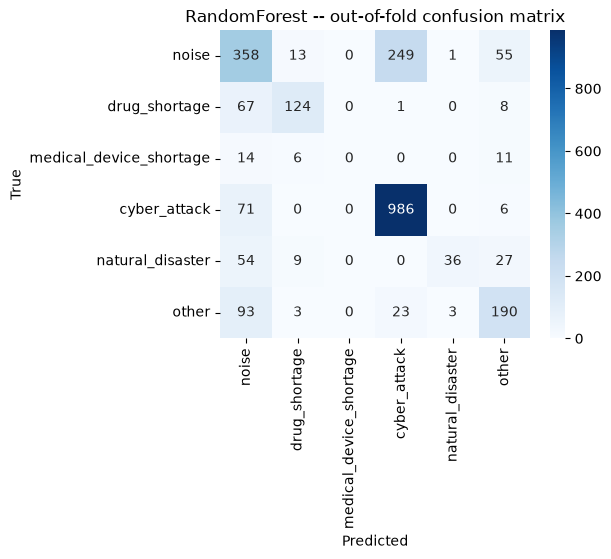

LogisticRegression
Accuracy per fold: [0.6722 0.6577 0.6992 0.6445 0.6299]
Mean accuracy: 0.6607 ± 0.0238

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.52      0.50      0.51       676
          drug_shortage       0.72      0.72      0.72       200
medical_device_shortage       0.26      0.16      0.20        31
           cyber_attack       0.78      0.80      0.79      1063
       natural_disaster       0.62      0.54      0.58       126
                  other       0.55      0.60      0.57       312

               accuracy                           0.66      2408
              macro avg       0.58      0.55      0.56      2408
           weighted avg       0.66      0.66      0.66      2408



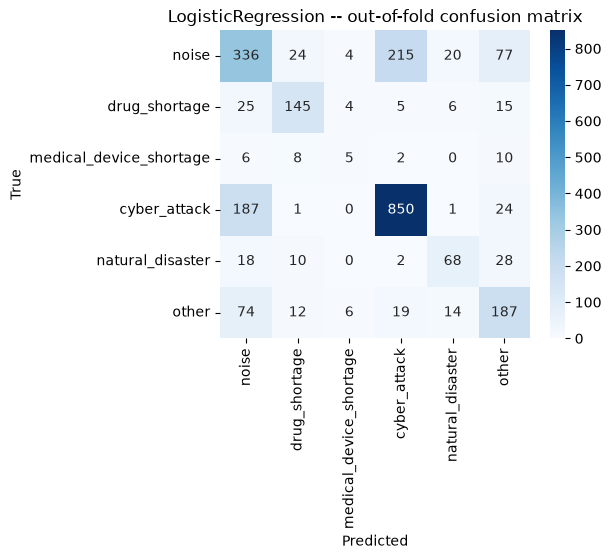

SVC
Accuracy per fold: [0.7531 0.7427 0.7552 0.7214 0.7193]
Mean accuracy: 0.7384 ± 0.0153

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.62      0.52      0.57       676
          drug_shortage       0.78      0.81      0.79       200
medical_device_shortage       0.00      0.00      0.00        31
           cyber_attack       0.80      0.91      0.85      1063
       natural_disaster       0.71      0.58      0.64       126
                  other       0.70      0.70      0.70       312

               accuracy                           0.74      2408
              macro avg       0.60      0.59      0.59      2408
           weighted avg       0.72      0.74      0.73      2408



/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

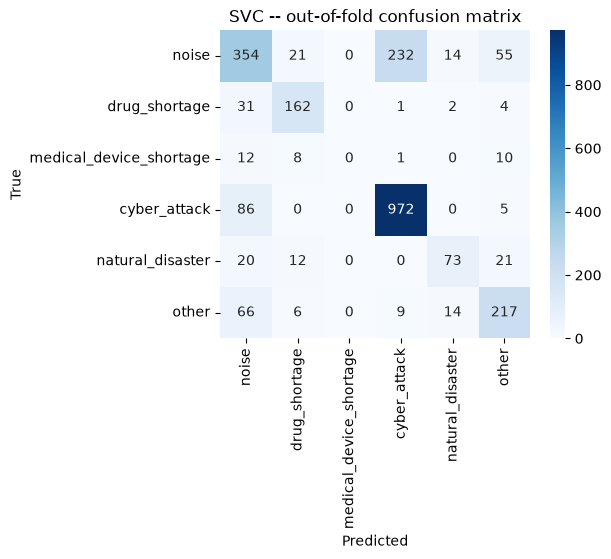

MLP
Accuracy per fold: [0.7241 0.6909 0.6826 0.7277 0.6798]
Mean accuracy: 0.7010 ± 0.0207

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.58      0.50      0.53       676
          drug_shortage       0.72      0.80      0.76       200
medical_device_shortage       0.23      0.10      0.14        31
           cyber_attack       0.79      0.85      0.82      1063
       natural_disaster       0.70      0.64      0.67       126
                  other       0.62      0.67      0.64       312

               accuracy                           0.70      2408
              macro avg       0.61      0.59      0.59      2408
           weighted avg       0.69      0.70      0.69      2408



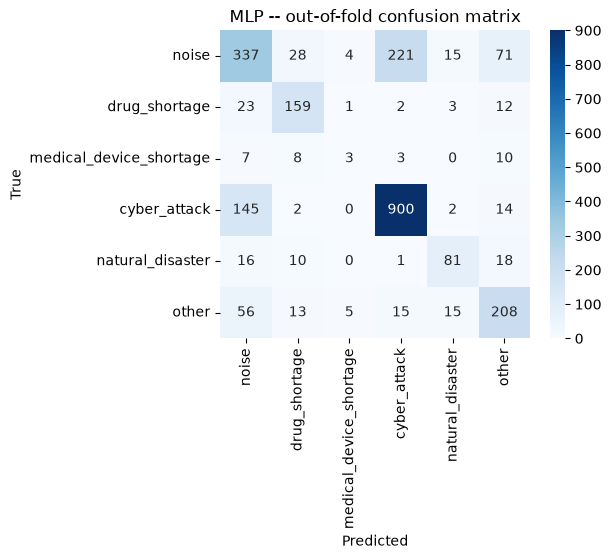

Summary -- algorithms ranked by mean 5-fold accuracy
------------------------------------------------------------
1. SVC                  0.7384 ± 0.0153
2. RandomForest         0.7035 ± 0.0183
3. MLP                  0.7010 ± 0.0207
4. LogisticRegression   0.6607 ± 0.0238


In [ ]:
run_experiment(X_classic,y)

# BERT

In [45]:
bert_path = "google-bert/bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(bert_path)

model = AutoModelForSequenceClassification.from_pretrained(
    bert_path,
    num_labels = 6,
    id2label = IDX_TO_LABEL,
    label2id = LABEL_MAP,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [46]:
# freeze base model parameters
for name, param in model.base_model.named_parameters():
    param.requires_grad = False

# unfreeze base model pooling layers
for name, param in model.base_model.named_parameters():
    if "pooler" in name:
        param.requires_grad = True